# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [1]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Đã `git clone` repo bài lab vào thư mục này (đổi nếu bạn đặt chỗ khác).
REPO_DIR = "K4-Track4-Day2-Deeplearning-Advance"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, f"{REPO_DIR}/starter")    # hoặc thư mục code/ của bạn sau khi chép starter vào

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python 3.10.19 | torch 2.5.1 | timm 1.0.24
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [ ]:
import hashlib

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

!unzip -q -n data/images.zip -d data/
!ls data | head

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

In [3]:
IMAGES_DIR = "data/images"   # TODO: kiểm tra đúng thư mục chứa các file .jpg sau khi giải nén
LABELS_DIR = "data/labels"

## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

=== SỐ LƯỢNG ẢNH MỖI TẬP ===
Train : 10501 ảnh
Val   : 3501 ảnh
Test  : 3507 ảnh
Total : 17509 ảnh

=== ĐỐI CHIẾU SỐ LƯỢNG MỖI LỚP (Table 1 bài báo) ===
                train   val  test  Total  Paper_Table1  Diff
Chinee Apple      675   225   226   1126          1125     1
Lantana           637   213   213   1063          1064    -1
Parkinsonia       618   206   207   1031          1031     0
Parthenium        613   204   205   1022          1022     0
Prickly Acacia    637   212   213   1062          1062     0
Rubber Vine       605   202   202   1009          1009     0
Siam Weed         644   215   215   1074          1074     0
Snake Weed        609   203   204   1016          1016     0
Negatives        5463  1821  1822   9106          9106     0


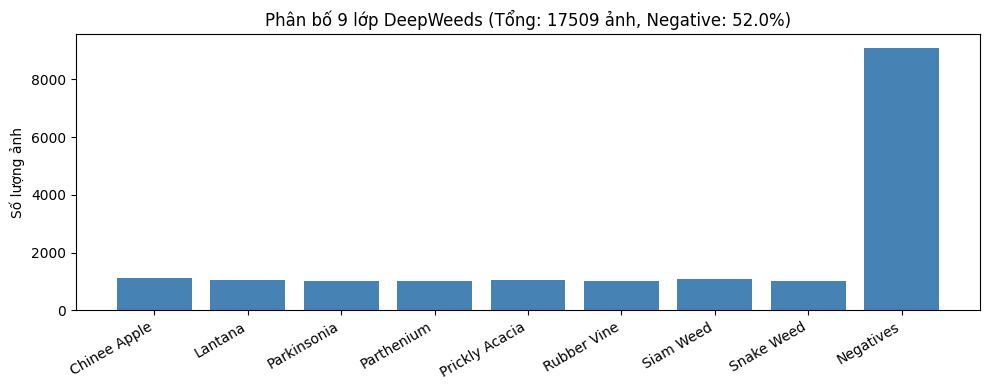

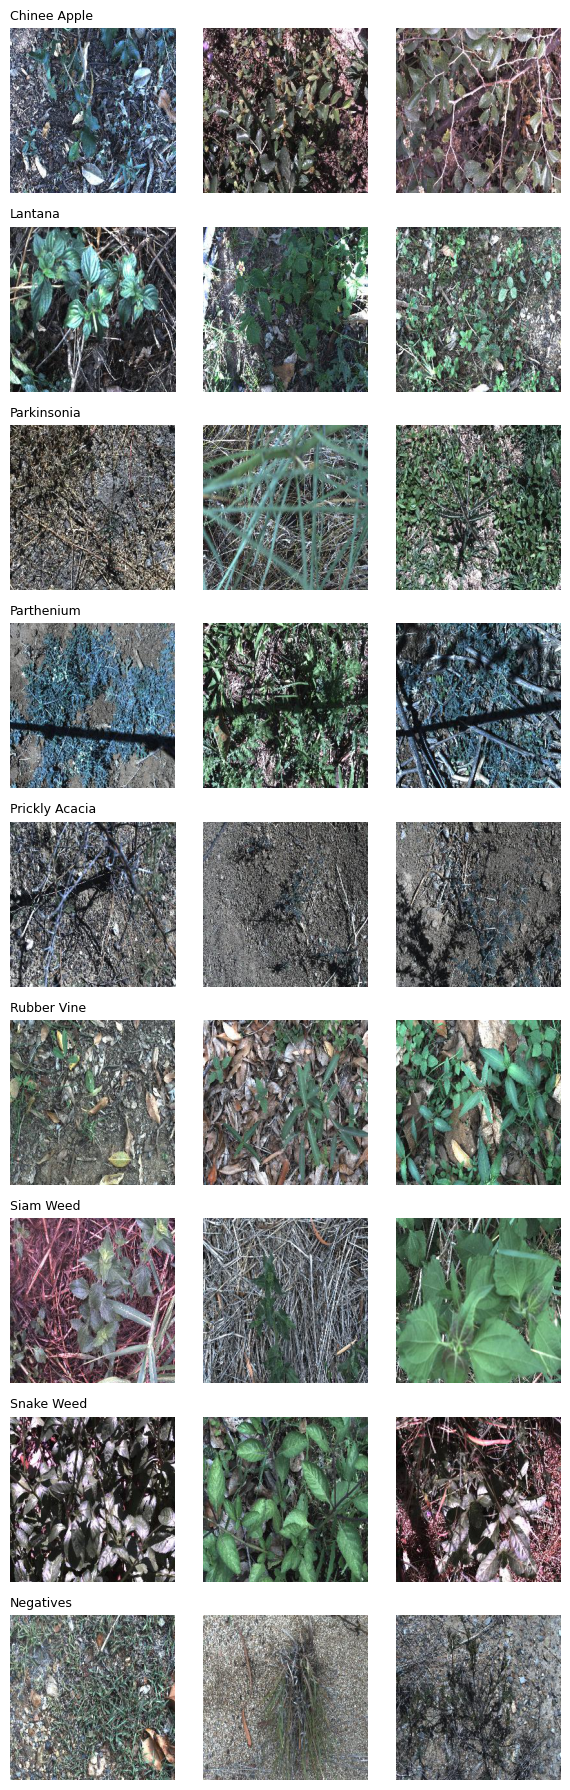

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from dataset import CLASS_NAMES, check_split, load_split

# Định vị thư mục (hỗ trợ cả chạy từ gốc repo hoặc từ thư mục code/)
labels_path = Path(LABELS_DIR if "LABELS_DIR" in globals() else "data/labels")
images_path = Path(IMAGES_DIR if "IMAGES_DIR" in globals() else "data/images")
if not labels_path.exists():
    labels_path = Path("../../data/labels")
    images_path = Path("../../data/images")

out_dir = Path("curves")
out_dir.mkdir(parents=True, exist_ok=True)

# 1. Đọc và kiểm tra split (S1-S4)
train_df, val_df, test_df = load_split(labels_path, fold=0)
stats = check_split(train_df, val_df, test_df, images_path)

print("=== SỐ LƯỢNG ẢNH MỖI TẬP ===")
for split_name, count in stats["n"].items():
    print(f"{split_name.capitalize():<6}: {count} ảnh")

print("\n=== ĐỐI CHIẾU SỐ LƯỢNG MỖI LỚP (Table 1 bài báo) ===")
df_per_class = pd.DataFrame(stats["per_class"])
df_per_class.index = [CLASS_NAMES[i] for i in df_per_class.index]
df_per_class["Total"] = df_per_class.sum(axis=1)
df_per_class["Paper_Table1"] = [1125, 1064, 1031, 1022, 1062, 1009, 1074, 1016, 9106]
df_per_class["Diff"] = df_per_class["Total"] - df_per_class["Paper_Table1"]
print(df_per_class)

# 2. Vẽ biểu đồ phân bố 9 lớp
labels_full = pd.concat([train_df, val_df, test_df])
counts = labels_full["Label"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar([CLASS_NAMES[i] for i in counts.index], counts.values, color="steelblue")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Số lượng ảnh")
plt.title(f"Phân bố 9 lớp DeepWeeds (Tổng: {len(labels_full)} ảnh, Negative: {counts[8]/len(labels_full)*100:.1f}%)")
plt.tight_layout()
plt.savefig(out_dir / "class_distribution.png", dpi=200)
plt.show()

# 3. Trực quan hóa 3 ảnh mỗi lớp và kiểm tra kích thước
fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(6, 18))
for c_idx, c_name in enumerate(CLASS_NAMES):
    samples = labels_full[labels_full["Label"] == c_idx].head(3)
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = images_path / row["Filename"]
        img = Image.open(img_path)
        assert img.size == (256, 256), f"Kích thước sai: {img.size}"
        axes[c_idx, i].imshow(img)
        axes[c_idx, i].axis("off")
        if i == 0:
            axes[c_idx, i].set_title(c_name, loc="left", fontsize=9)

plt.tight_layout()
plt.savefig(out_dir / "sample_classes.png", dpi=200)
plt.show()


In [12]:
# TODO: kiểm tra pipeline (slide trang 59, GUIDE.md mục 1.3):
#   1) cố định seed
#   2) loss ban đầu của head mới xấp xỉ -ln(1/9) = 2.197
#   3) overfit được một batch nhỏ tới loss gần 0
#   4) vẽ vài ảnh sau augmentation (đã giải chuẩn hoá) cùng nhãn để chắc ảnh và nhãn khớp nhau

import math
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from dataset import IMAGENET_MEAN, IMAGENET_STD, CLASS_NAMES, build_transforms, load_split, make_loader
import model as md
from train import set_seed

# Đảm bảo có sẵn đường dẫn và dữ liệu nếu chạy riêng cell này
img_p = Path(images_path if "images_path" in globals() else "data/images")
if not img_p.exists():
    img_p = Path("../../data/images")

if "train_df" not in globals():
    lbl_p = Path(labels_path if "labels_path" in globals() else "data/labels")
    if not lbl_p.exists():
        lbl_p = Path("../../data/labels")
    train_df, _, _ = load_split(lbl_p, fold=0)

# 1. Cố định Seed
set_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 2. Kiểm tra Initial Loss (xấp xỉ -ln(1/9) ≈ 2.197)
net = md.build_model("resnet50", pretrained=True, num_classes=9, init="finetune").to(device)
criterion = nn.CrossEntropyLoss()

dummy_x = torch.randn(8, 3, 224, 224, device=device)
dummy_y = torch.randint(0, 9, (8,), device=device)

with torch.no_grad():
    init_logits = net(dummy_x)
    init_loss = criterion(init_logits, dummy_y).item()

expected_loss = -math.log(1.0 / 9.0)
print(f"\n[Test 1] Initial Loss: {init_loss:.4f} (Kỳ vọng: {expected_loss:.4f})")
assert abs(init_loss - expected_loss) < 0.5, f"Lỗi: Initial loss lệch quá xa ({init_loss})"
print("=> Initial Loss: PASS")

# 3. Kiểm tra Overfit 1 batch nhỏ (4-8 mẫu) về loss sát 0 (< 0.05)
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)
print("\n[Test 2] Overfitting 1 small batch (8 samples)...")
for step in range(1, 81):
    net.train()
    optimizer.zero_grad()
    outputs = net(dummy_x)
    loss = criterion(outputs, dummy_y)
    loss.backward()
    optimizer.step()
    if step % 20 == 0:
        print(f"Step {step:2d} | Loss: {loss.item():.4f}")

assert loss.item() < 0.05, f"Lỗi: Không overfit được batch nhỏ, loss còn {loss.item():.4f}"
print("=> Overfit Small Batch: PASS")

# 4. Trực quan hóa ảnh sau Augmentation (đã giải chuẩn hóa)
train_tf = build_transforms(train=True, img_size=224, aug="basic")
train_loader = make_loader(train_df, img_p, train_tf, batch_size=4, train=True)
images, labels, filenames = next(iter(train_loader))

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    unnorm_img = images[i].cpu() * std + mean
    unnorm_img = torch.clamp(unnorm_img, 0.0, 1.0).permute(1, 2, 0).numpy()
    axes[i].imshow(unnorm_img)
    axes[i].set_title(f"{CLASS_NAMES[labels[i]]}", fontsize=10)
    axes[i].axis("off")
plt.suptitle("Kiểm tra ảnh và nhãn sau Augmentation", y=1.05)
plt.tight_layout()
plt.show()
print("=> Augmentation check: PASS")


ModuleNotFoundError: No module named 'model'

## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [ ]:
# ==============================================================================
# Bước 1 — So sánh backbone (≥ 5)
# ==============================================================================
import time
from pathlib import Path
import pandas as pd
import torch
from train import Config, run
from benchmark import latency_report
import model as md

# 1.1 Danh sách 5 Backbone đại diện 4 họ (GUIDE mục 2.1)
BACKBONES = [
    {"exp_id": "B01", "name": "resnet50", "family": "ResNet (Baseline)"},
    {"exp_id": "B02", "name": "convnext_tiny", "family": "ConvNeXt (Modern CNN)"},
    {"exp_id": "B03", "name": "swin_tiny_patch4_window7_224", "family": "Transformer (Swin)"},
    {"exp_id": "B04", "name": "efficientnet_b0", "family": "Lightweight (EfficientNet)"},
    {"exp_id": "B05", "name": "mobilenetv3_large_100", "family": "Lightweight (MobileNetV3)"},
]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Bắt đầu huấn luyện so sánh 5 Backbone trên device: {device}\n")

results_backbones = []

# 1.2 Vòng lặp huấn luyện từng backbone bằng công thức nền T00
for b in BACKBONES:
    exp_id = b["exp_id"]
    name = b["name"]
    print("=" * 60)
    print(f"Đang chạy thí nghiệm: {exp_id} - {name} ({b['family']})")
    print("=" * 60)

    cfg = Config(
        exp_id=exp_id,
        backbone=name,
        epochs=12,
        seed=0,
        save_test_predictions=False,
    )

    t_start = time.time()
    res = run(cfg)
    train_time = time.time() - t_start

    # 1.3 Đo độ trễ sơ bộ (batch 1, 1x3x224x224) trên best checkpoint
    print(f"Đo độ trễ suy luận batch=1 cho {name}...")
    best_model = md.build_model(name, pretrained=False, num_classes=9, init="scratch")
    best_ckpt = Path(cfg.out_dir) / exp_id / f"seed{cfg.seed}" / "best_model.pt"
    if best_ckpt.exists():
        best_model.load_state_dict(torch.load(best_ckpt, map_location=device))

    lat_info = latency_report(best_model, batch_size=1, img_size=cfg.img_size, device=device, warmup=10, iters=50)

    weight_tag = getattr(best_model, "default_cfg", {}).get("tag", "default")
    if weight_tag is None:
        weight_tag = "default"

    row = {
        "exp_id": exp_id,
        "backbone": name,
        "family": b["family"],
        "tag": weight_tag,
        "params_m": round(res["params_m"], 2),
        "gmacs": round(res["gmacs"], 2),
        "val_macro_f1": round(res["best_val_macro_f1"], 4),
        "best_epoch": res["best_epoch"],
        "time_per_epoch_s": round(res["time_per_epoch_s"], 1),
        "latency_p50_ms": round(lat_info["p50"], 2),
        "latency_p95_ms": round(lat_info["p95"], 2),
        "throughput_img_s": round(lat_info["images_per_s"], 1),
    }
    results_backbones.append(row)
    print(f"Hoàn thành {exp_id}: Best F1={row['val_macro_f1']} | Latency p50={row['latency_p50_ms']}ms\n")

# Hiển thị bảng tổng hợp
df_backbones = pd.DataFrame(results_backbones)
Path("runs").mkdir(exist_ok=True)
df_backbones.to_csv("runs/backbones_summary.csv", index=False)
print("\n=== BẢNG TỔNG HỢP BACKBONE (Sheet Backbones) ===")
try:
    from IPython.display import display
    display(df_backbones)
except Exception:
    print(df_backbones)


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [ ]:
# TODO: các trục A-G của GUIDE.md mục 3 (khởi tạo, augmentation, loss, sampler, LR/optimizer, EMA, ...).
# TODO: thử ít nhất một kết hợp các yếu tố tốt; so Δ với nhiễu (std).

## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [ ]:
# TODO: TTA lật, multi-crop/scale, dò độ phân giải, gộp xác suất vs logit, ensemble, EMA/soup,
#       temperature scaling (T khớp trên VAL), gộp BN/FP16  (starter/inference.py)
# TODO: độ trễ p50/p95/p99 bằng starter/benchmark.py: warmup, synchronize, >= 50 lần

## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [ ]:
# TODO: chạy chung kết và mốc, mỗi seed, ví dụ:
#   for seed in (0, 1, 2):
#       run(Config(exp_id="F01", ..., seed=seed, save_test_predictions=True))
#       run(Config(exp_id="T00", seed=seed, save_test_predictions=True))
# Với suy luận (TTA/ensemble/temperature scaling), tự ghi predictions/F01_seed<k>_test.csv
# bằng eval.save_predictions(...) từ xác suất cuối cùng; thêm F01uncal_* nếu muốn chấm I4(a).

In [ ]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag F01 --out eval_out
!python {REPO_DIR}/eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag T00 --out eval_out

In [ ]:
# Tự chấm phần I của RUBRIC (đề xuất, giảng viên xác nhận). Thêm --uncal, --final-val, --latency-p95-ms nếu có.
!python {REPO_DIR}/eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --out eval_out

## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [ ]:
# TODO: ghi results.xlsx bằng pandas.ExcelWriter(engine="openpyxl") với các sheet:
#   Backbones, Training, Inference, Final, PerClass, Latency, Summary
# TODO: kiểm tra mỗi exp_id có ảnh trong curves/ và số trong xlsx khớp kết quả của eval.py